In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from scipy.stats import randint

In [3]:
df = pd.read_csv("data.csv")

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [6]:
df.drop(["id","Unnamed: 32"], axis=1, inplace=True)

In [7]:
df["diagnosis"] = df["diagnosis"].map({
    "M":1,
    "B":0
})

In [8]:
X = df.drop("diagnosis", axis=1)

y = df["diagnosis"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [11]:
baseline = DecisionTreeClassifier(random_state=42)

baseline.fit(X_train,y_train)

baseline_pred = baseline.predict(X_test)

In [12]:
baseline_accuracy = accuracy_score(y_test,baseline_pred)

print(baseline_accuracy)

0.9298245614035088


In [13]:
cv_scores = cross_val_score(
    baseline,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print(cv_scores)

print("Average Accuracy:",cv_scores.mean())

[0.96703297 0.95604396 0.91208791 0.93406593 0.89010989]
Average Accuracy: 0.9318681318681318


In [14]:
param_grid = {
    "max_depth":[3,5,7,10,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4],
    "criterion":["gini","entropy"]
}

In [15]:
grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [16]:
print(grid.best_params_)

{'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 5}


In [17]:
grid_model = grid.best_estimator_

grid_pred = grid_model.predict(X_test)

In [18]:
param_dist = {
    "max_depth":randint(2,15),
    "min_samples_split":randint(2,15),
    "min_samples_leaf":randint(1,8),
    "criterion":["gini","entropy"]
}

In [19]:
random_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train,y_train)

RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7b50d76fa0c0>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7b50d677d340>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7b50d677e180>},
                   random_state=42, scoring='accuracy')

In [20]:
print(random_search.best_params_)

{'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 5}


In [21]:
random_model = random_search.best_estimator_

random_pred = random_model.predict(X_test)

In [22]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

In [23]:
def evaluate(y_true,y_pred):

    return [

        accuracy_score(y_true,y_pred),

        precision_score(y_true,y_pred),

        recall_score(y_true,y_pred),

        f1_score(y_true,y_pred)

    ]

In [24]:
results = pd.DataFrame({

    "Model":[

        "Baseline Decision Tree",

        "GridSearchCV",

        "RandomizedSearchCV",

        "Random Forest"

    ],

    "Accuracy":[

        evaluate(y_test,baseline_pred)[0],

        evaluate(y_test,grid_pred)[0],

        evaluate(y_test,random_pred)[0],

        evaluate(y_test,rf_pred)[0]

    ],

    "Precision":[

        evaluate(y_test,baseline_pred)[1],

        evaluate(y_test,grid_pred)[1],

        evaluate(y_test,random_pred)[1],

        evaluate(y_test,rf_pred)[1]

    ],

    "Recall":[

        evaluate(y_test,baseline_pred)[2],

        evaluate(y_test,grid_pred)[2],

        evaluate(y_test,random_pred)[2],

        evaluate(y_test,rf_pred)[2]

    ],

    "F1 Score":[

        evaluate(y_test,baseline_pred)[3],

        evaluate(y_test,grid_pred)[3],

        evaluate(y_test,random_pred)[3],

        evaluate(y_test,rf_pred)[3]

    ]

})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline Decision Tree,0.929825,0.904762,0.904762,0.904762
1,GridSearchCV,0.956140,1.000000,0.880952,0.936709
2,RandomizedSearchCV,0.938596,1.000000,0.833333,0.909091
3,Random Forest,0.973684,1.000000,0.928571,0.962963


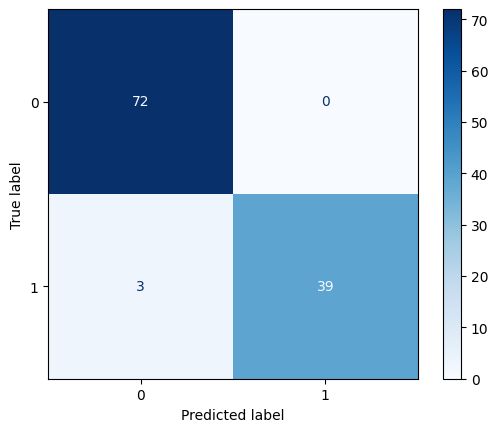

In [25]:
cm = confusion_matrix(y_test,rf_pred)

ConfusionMatrixDisplay(cm).plot(cmap="Blues")

plt.show()

In [ ]:
# Conclusion

A baseline Decision Tree model was first trained and evaluated using 5-fold Cross Validation to estimate its performance on unseen data. Hyperparameter tuning was then performed using both GridSearchCV and RandomizedSearchCV to improve the model by finding better parameter combinations. Finally, a Random Forest ensemble model was trained and compared with the other models. Based on the Accuracy, Precision, Recall, and F1-score, the Random Forest model achieved the best overall performance because it combines multiple decision trees, reduces overfitting, and provides better generalization on unseen data.